In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
assets = {
    "NIFTY": "^NSEI",
    "TCS": "TCS.NS",
    "RELIANCE": "RELIANCE.NS"
}
prices = yf.download(
    list(assets.values()),
         start="2024-01-01",
         end="2025-01-01"
)["Close"]

[*********************100%***********************]  3 of 3 completed


In [3]:
returns = prices.pct_change(fill_method=None).dropna() * 100
print(returns.head())

Ticker      RELIANCE.NS    TCS.NS     ^NSEI
Date                                       
2024-01-02     0.828102 -0.732070 -0.350014
2024-01-03    -1.087402 -2.417278 -0.685187
2024-01-04     0.516761 -0.675828  0.656447
2024-01-05     0.425553  1.939016  0.241018
2024-01-08    -0.780368 -1.594461 -0.911071


In [4]:
weights = np.array([0.5, 0.2, 0.3])

In [5]:
mean_returns = returns.mean()

In [6]:
mean_returns

Ticker
RELIANCE.NS   -0.014123
TCS.NS         0.045862
^NSEI          0.038199
dtype: float64

In [7]:
cov_matrix = returns.cov()
cov_matrix

Ticker,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,
RELIANCE.NS,2.089464,0.517606,0.964993
TCS.NS,0.517606,1.781585,0.508627
^NSEI,0.964993,0.508627,0.788120


In [8]:
def montecarlo_var(
    mean_returns,
    cov_matrix,
    weights,
    confidence_level,
    n_simulations=100000
):
    simulated_returns = np.random.multivariate_normal(
        mean_returns,
        cov_matrix,
        n_simulations
    )

    portfolio_returns = simulated_returns @ weights

    var = np.percentile(
        portfolio_returns,
        (1 - confidence_level) * 100
    )
    return portfolio_returns, var

In [9]:
portfolio_returns, var_95 = montecarlo_var(
    mean_returns,
    cov_matrix,
    weights,
    0.95,
    100000
)
_, var_99 = montecarlo_var(
    mean_returns,
    cov_matrix,
    weights,
    0.99,
    100000
)

print(f"95% Monte Carlo VaR: {abs(var_95):.2f}")
print(f"99% Monte Carlo VaR: {abs(var_99):.2f}")

95% Monte Carlo VaR: 1.73
99% Monte Carlo VaR: 2.44


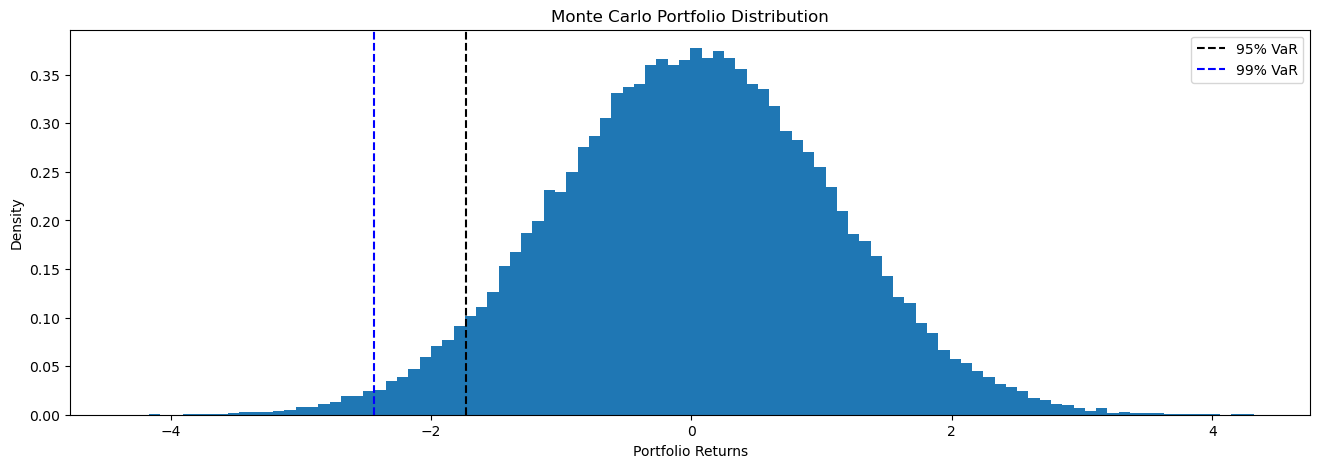

In [10]:
# Visualization
plt.figure(figsize=(16,5))

plt.hist(
    portfolio_returns,
    bins=100,
    density=True
)

plt.axvline(
    var_95,
    linestyle="--",
    label="95% VaR",
    color="black"
)
plt.axvline(
    var_99,
    linestyle="--",
    label="99% VaR",
    color="blue"
)

plt.title("Monte Carlo Portfolio Distribution")
plt.xlabel("Portfolio Returns")
plt.ylabel("Density")
plt.legend()
plt.show()